# Long-form inference experiments - analysis

In [1]:
# stdlib
from collections import Counter
import itertools
import os
from typing import Tuple, Iterable
from multiprocessing import Pool
from pathlib import Path

# third-party
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm import tqdm
import numpy as np
import jiwer
from alt_eval import metrics
from alt_eval.tokenizer import WORD, BACKING, NONLEXICAL
import rapidfuzz
import nltk

# first-party
from alt import util
from alt import evaluate
from alt.alt_types import SongInfo
from alt_eval.tokenizer import Token

sns.set_theme()
project_root = Path(os.getcwd()).parent.parent
print(f"Home dir: {os.getenv('HOME')}")
print(f"Working dir: {os.getcwd()}")
print(f"Project root: {project_root}")


Home dir: /homes/js231
Working dir: /homes/js231/code/alt/expt/04-long
Project root: /homes/js231/code/alt


In [2]:
data: dict[Tuple[str, str, str], list[Tuple[SongInfo, jiwer.WordOutput]]] = dict()


def eval_song(name, uid) -> Tuple[SongInfo, jiwer.WordOutput]:
    songinfo = util.read_pz(f"../../build/{name}/infer/{uid}.pz")
    eval_data, wo = evaluate.eval_song(songinfo)
    songinfo.evaluate = eval_data
    return songinfo, wo


LONG_DATASETS = ["jam-alt", "musdb-alt"]

models = ["whisper"]  
algos = ["base", "rmsvad"]
targets = ["original", "separated", "stem"]
DEMUCS_MODEL_NAME = "mdx_extra"
for model, target, algo in tqdm(list(itertools.product(models, targets, algos))):
    if target == "separated" or algo == "rmsvad":
        name = f"04-long-{DEMUCS_MODEL_NAME}-{model}-{target}-{algo}"
    else:
        name = f"04-long-{model}-{target}-base"
    print(name)

    # Read actual data
    if False:
        uids = util.read_summary(f"../../build/{name}/infer/summary.json").infer.uids  # type: ignore
        uids = [uid for uid in uids if uid.endswith("jam-alt") or uid.endswith("musdb-alt")]
        data[(model, target, algo)] = Pool(20).starmap(
            eval_song, [(name, uid) for uid in uids]
        )
        data[(model, target, algo)] = [
            (s, wo)
            for s, wo in data[(model, target, algo)]
            if s.extract.dataset_id in LONG_DATASETS
        ]
    else:
        data[(model, target, algo)] = []
        for idx in range(5):
            name_idx = f"{name}-{idx}"
            uids = util.read_summary(f"../../build/{name_idx}/infer/summary.json").infer.uids  # type: ignore
            uids = [uid for uid in uids if uid.endswith("jam-alt") or uid.endswith("musdb-alt")]
            results= Pool(20).starmap(
                eval_song, [(name_idx, uid) for uid in uids]
            )
            data[(model, target, algo)].extend(results)

            



  0%|          | 0/6 [00:00<?, ?it/s]

04-long-whisper-original-base


/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at JamendoLyricsConfig.path: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at JamAltConfig.line_timings_path: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at MusdbAltConfig.musdb_dir: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at M

04-long-mdx_extra-whisper-original-rmsvad


 33%|███▎      | 2/6 [00:19<00:40, 10.13s/it]

...

 67%|██████▋   | 4/6 [00:40<00:20, 10.09s/it]

04-long-whisper-stem-base


 83%|████████▎ | 5/6 [00:51<00:10, 10.35s/it]

04-long-mdx_extra-whisper-stem-rmsvad


100%|██████████| 6/6 [00:59<00:00,  9.98s/it]


Convert results to Dataframe

In [ ]:
# edits_df and chunks_df - same as ondrej script
# normal analysis on edits_df
# chunks_df can be used to identify long insertions and deletions -- and print them because we can attach the text!
# hallucinations, missing sections - can show that these

REF_TAGS = {NONLEXICAL, BACKING}

def get_chunk_edits(
    reference: list[Token],
    hypothesis: list[Token],
    chunk_type: str,
) -> list[Tuple[str, str, str, set]]:
    edits = []

    if chunk_type == "delete":
        assert len(hypothesis) == 0
        for token in reference:
            edits.append(("del", token.text, None, token.tags & REF_TAGS))
    elif chunk_type == "insert":
        assert len(reference) == 0
        for token in hypothesis:
            edits.append(("ins", None, token.text, {}))
    elif chunk_type in ["substitute", "equal"]:
        assert len(reference) == len(hypothesis)
        for token_ref, token_hyp in zip(reference, hypothesis):
            edits.append(
                (
                    "hit" if chunk_type == "equal" else "sub",
                    token_ref.text,
                    token_hyp.text,
                    token_ref.tags & REF_TAGS,
                )
            )
    else:
        assert False, f"Unhandled chunk type: {chunk_type}"
    return edits


def word_dist(w1, w2):
    if w1 is None or w2 is None:
        return np.nan
    w1 = w1.replace("'", "")
    w2 = w2.replace("'", "")
    return rapidfuzz.distance.Levenshtein.distance(w1, w2)


def count_ngram_dup(tokens: Iterable[str], ngram_len: int) -> int:
    counter = Counter(nltk.ngrams(tokens, ngram_len))
    duplicates = sum(count - 1 for gram, count in counter.items() if count > 1)
    return duplicates


tokenizer = metrics.LyricsTokenizer()

map_type = {
    "insert": "ins",
    "equal": "hit",
    "delete": "del",
    "substitute": "sub",
}


def song_to_rows(
    songinfo: SongInfo, wo: jiwer.WordOutput
) -> Tuple[dict, list[dict], list[dict]]:
    assert songinfo.evaluate is not None
    ref_tokens_all = [
        metrics.tokens_as_words(tokenizer(ref, language=songinfo.extract.language))
        for ref in songinfo.evaluate.refs
    ]
    hyp_tokens_all = [
        metrics.tokens_as_words(tokenizer(hyp, language=songinfo.extract.language))
        for hyp in songinfo.evaluate.hyps
    ]
    edit_counts, _error_counts = metrics.process_alignments(
        ref_tokens_all, hyp_tokens_all, wo.alignments
    )
    e = edit_counts[WORD]
    en = edit_counts[NONLEXICAL]
    eb = edit_counts[BACKING]
    uid = songinfo.extract.uid
    dataset = songinfo.extract.dataset_id
    language = songinfo.extract.language

    song_row = {
        "wer": (e.S + e.D + e.I) / (e.H + e.S + e.D),
        "hit": e.H,
        "sub": e.S,
        "del": e.D,
        "ins": e.I,
        # you can at least show that deletions of nonlexical lines
        # are a high percentage of the error rate
        # en.x + eb.x <= e.x for x in {H, S, D}
        "hit_nl": en.H,
        "sub_nl": en.S,
        "del_nl": en.D,
        "hit_bv": eb.H,
        "sub_bv": eb.S,
        "del_bv": eb.D,
        "len": (e.H + e.S + e.D),
        "uid": uid,
        "dataset": dataset,
        "language": language,
        "ref": "\n".join(songinfo.evaluate.refs),
        "hyp": "\n".join(songinfo.evaluate.hyps),
        "audio_fn": songinfo.extract.audio_fn
    }
    edit_rows = []
    chunk_rows = []
    for hyp_tokens, ref_tokens, alignment in zip(
        hyp_tokens_all, ref_tokens_all, wo.alignments
    ):
        for idx, chunk in enumerate(alignment):
            chunk_hyp = hyp_tokens[chunk.hyp_start_idx : chunk.hyp_end_idx]
            chunk_ref = ref_tokens[chunk.ref_start_idx : chunk.ref_end_idx]
            chunk_row = (
                {
                    "typ": map_type[chunk.type],
                    "ref": " ".join(token.text for token in chunk_ref),
                    "hyp": " ".join(token.text for token in chunk_hyp),
                    # len will be same for sub/hit and the non-zero one for del/ins
                    "len": max(
                        chunk.hyp_end_idx - chunk.hyp_start_idx,
                        chunk.ref_end_idx - chunk.ref_start_idx,
                    ),
                    "uid": uid,
                    "dataset": dataset,
                    "language": language,
                    "idx": idx,
                    "nl": 0,
                    "bv": 0,
                }
            )
            for op, edit_ref, edit_hyp, tags in get_chunk_edits(
                chunk_ref, chunk_hyp, chunk.type
            ):
                if NONLEXICAL in tags:
                    chunk_row["nl"] += 1
                if BACKING in tags:
                    chunk_row["bv"] += 1
                edit_rows.append(
                    {
                        "typ": op,
                        "ref": edit_ref,
                        "hyp": edit_hyp,
                        "uid": uid,
                        "dataset": dataset,
                        "language": language,
                        "dist": word_dist(edit_ref, edit_hyp),
                        "nl": NONLEXICAL in tags,
                        "bv": BACKING in tags,
                    }
                )
            chunk_rows.append(chunk_row)
    return (song_row, chunk_rows, edit_rows)


# Convert each songinfo / wordoutput to a summary + list of edits
# songinfo, wo = data[("whisper", "original", "base")][65]
# song, chunks, edits = song_to_rows(songinfo, wo)
# print(songinfo.extract.uid)


def get_data_rows(system, sample_data) -> Tuple[list[dict], list[dict], list[dict]]:
    (model, target, algo) = system
    system = {"model": model, "target": target, "algo": algo}
    rows = [song_to_rows(*s_wo) for s_wo in sample_data]
    song_rows = [song | system for song, _, _ in rows]
    chunk_rows = [chunk | system for _, chunks, _ in rows for chunk in chunks]
    edit_rows = [edit | system for _, _, edits in rows for edit in edits]
    return song_rows, chunk_rows, edit_rows

system_rows = Pool(20).starmap(get_data_rows, tqdm(list(data.items())))
df_songs = pd.DataFrame(
    song_row for song_rows, _, _ in system_rows for song_row in song_rows
)
df_edits = pd.DataFrame(
    edit_row for _, _, edit_rows in system_rows for edit_row in edit_rows
)
# df_edits["dist"] = df_edits.apply(lambda row: word_dist(row["ref"], row["hyp"]), axis=1)
df_chunks = pd.DataFrame(
    chunk_row for _, chunk_rows, _ in system_rows for chunk_row in chunk_rows
)

util.write_pz(project_root / "share" / "data_long.pz", (df_songs, df_chunks, df_edits))


## Analysis

In [ ]:
(df_songs, df_chunks, df_edits) = util.read_pz(project_root / "share" / "data_long.pz")

,wer,hit,sub,del,ins,hit_nl,sub_nl,del_nl,hit_bv,sub_bv,...,len,uid,dataset,language,ref,hyp,audio_fn,model,target,algo
0,0.137072,287,21,13,10,0,0,0,0,0,...,321,Burn_Out_Man_-_Abendblau_jam-alt,jam-alt,de,"Mannomann, am Ende des Tages ist immer noch Ar...","Mann, oh Mann, am Ende des Tages ist immer no...",/homes/js231/.cache/huggingface/hub/datasets--...,whisper,original,base
1,0.215297,282,62,9,5,0,0,0,0,0,...,353,Bitte_beweg_dich_nicht_-_Bukto_jam-alt,jam-alt,de,"Du bist es nicht, die so sehr für eine Sache b...","Du bist es nicht, die so sehr Für eine Sache ...",/homes/js231/.cache/huggingface/hub/datasets--...,whisper,original,base
2,0.067568,138,9,1,0,0,0,0,0,0,...,148,Da_wurdest_du_geboren_-_Alice_Tlustos__jam-alt,jam-alt,de,Hoffnungslos im Dunkel meines Seins raste ich ...,"Hoffnungslos im Dunkel meines Seins, raste ic...",/homes/js231/.cache/huggingface/hub/datasets--...,whisper,original,base
3,0.163934,314,46,6,8,0,0,0,26,10,...,366,1_Freak_-_Automatisch_Gekommen_jam-alt,jam-alt,de,Ich würd' so gerne meinen Namen verlieren\n(Da...,"Ich würde so gerne meinen Namen verlieren, da...",/homes/js231/.cache/huggingface/hub/datasets--...,whisper,original,base
4,0.569892,78,13,2,38,0,0,0,0,0,...,93,Cafe_Jenseitz_Bebelstraße_-_kangaroo.musique_j...,jam-alt,de,Wo gibts den besten Milchkaffee\nHimbeer- oder...,Wo gibt's den besten Milchkaffee Im Meer oder...,/homes/js231/.cache/huggingface/hub/datasets--...,whisper,original,base
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370,0.166667,162,10,14,7,0,0,0,0,0,...,186,Secretariat_-_Borderline_musdb-alt,musdb-alt,en,Maybe there's hope for the city come summer\nW...,"Maybe there's hope for this city come summer,...",/homes/js231/data/musdb18hq/test/Secretariat -...,whisper,stem,base
1371,0.049689,157,4,0,4,0,0,0,0,0,...,161,Forkupines_-_Semantics_musdb-alt,musdb-alt,en,So here we are not making a scene\nCause that ...,"You\n So here we are not making a scene, caus...",/homes/js231/data/musdb18hq/test/Forkupines - ...,whisper,stem,base
1372,0.195122,245,9,33,14,0,0,0,0,0,...,287,The_Doppler_Shift_-_Atrophy_musdb-alt,musdb-alt,en,It's time to look back it's time to forget\nTi...,"You\n It's time to look back, it's time to fo...",/homes/js231/data/musdb18hq/test/The Doppler S...,whisper,stem,base
1373,0.010526,188,1,1,0,0,0,0,0,0,...,190,Speak_Softly_-_Broken_Man_musdb-alt,musdb-alt,en,Unwinding us like string cut away the rot\nWee...,"Unwinding us like string, cut away the rot We...",/homes/js231/data/musdb18hq/test/Speak Softly ...,whisper,stem,base


### Summary statistics

In [11]:
import librosa
def get_duration(audio_fn: str):
    y, sr = librosa.load(audio_fn, sr=None)  # sr=None ensures the original sample rate is used
    return librosa.get_duration(y=y, sr=sr)

df = df_songs.query("model == 'whisper' and algo == 'rmsvad' and target == 'original'").copy()
df['duration'] = df['audio_fn'].apply(get_duration)
df["len"] = df["hit"] + df["sub"] + df["del"]
df["nl"] = df["hit_nl"] + df["sub_nl"] + df["del_nl"]
df["bv"] = df["hit_bv"] + df["sub_bv"] + df["del_bv"]

# Group by 'dataset' and calculate metrics
result = df.groupby('dataset').agg(
    num_unique_uid=('uid', 'nunique'),  # Number of unique uids
    total_duration_mins=('duration', lambda x: x.sum() / 60),  # Total duration in minutes
    nl_len_percent=('nl', lambda x: (x.sum() / df.loc[x.index, 'len'].sum()) * 100),  # nl/len %
    bv_len_percent=('bv', lambda x: (x.sum() / df.loc[x.index, 'len'].sum()) * 100)  # bv/len %
).reset_index()

# Rename columns for clarity
result.columns = ['dataset', 'num_unique_uid', 'total_duration (mins)', 'nl/len %', 'bv/len %']

# Display the result
print(result)



     dataset  num_unique_uid  total_duration (mins)  nl/len %  bv/len %
0    jam-alt              79             283.294498  4.641750  4.658973
1  musdb-alt              39             166.338161  3.267368  4.901053


### Basic plots
Show error rates on different datasets for both algorithms and both targets

whisper: Mean WERs


/tmp/ipykernel_2367821/2840164250.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_wer)


/tmp/ipykernel_2367821/2840164250.py:39: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_2367821/2840164250.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
/tmp/ipykernel_2367821/2840164250.py:39: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_2367821/2840164250.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)


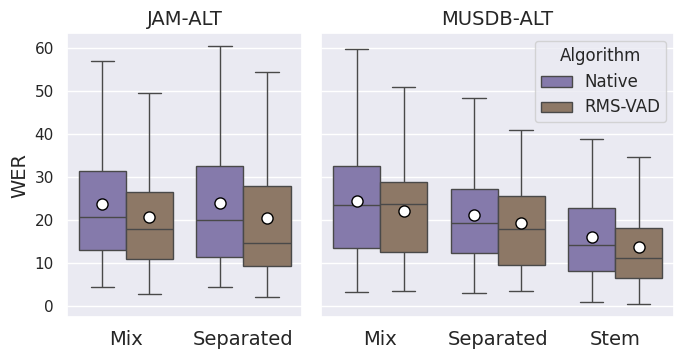

In [6]:
def combine_wer(rows):
    hit = rows["hit"].sum()
    ins = rows["ins"].sum()
    dels = rows["del"].sum()
    sub = rows["sub"].sum()
    wer = (ins + sub + dels) / (hit + sub + dels)
    return wer


plot = True
for model in ["whisper"]:
    pivot_table = (
        df_songs.query("model == @model and dataset in ['jam-alt', 'musdb-alt']")
        .groupby(["dataset", "target", "algo"])
        .apply(combine_wer)
        .reset_index(name="wer")
        .pivot(index=["dataset", "target"], columns="algo", values="wer")
        .reindex(["jam-alt", "musdb-alt"], level=0)
        .reindex(["original", "separated", "stem"], level=1)
    )
    print(f"{model}: Mean WERs")
    display((pivot_table * 100).style.format("{:.2f}"))

    plot_data = (df_songs
        .query("model == @model and algo != 'verse'")
        .replace({"algo": {"base": "Native", "rmsvad": "RMS-VAD", "verse": "Groups"}})
        .rename(columns={"algo": "Algorithm"})
        .replace({"target": {"original" : "Mix", "separated": "Separated", "stem": "Stem"}})
        .rename(columns={"target": "Audio"})
    )

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(7,3.75), sharey=True, gridspec_kw={"width_ratios": [2,3]})
        datasets = ["jam-alt", "musdb-alt"]
        colors = sns.color_palette()
        for ax, dataset in zip(axes, datasets):
            data = plot_data.query("dataset==@dataset").copy()
            data["wer"] *= 100
            sns.boxplot(
                data=data,
                x="Audio",
                y="wer",
                hue="Algorithm",
                ax=ax,
                showmeans=True,
                showfliers=False,
                palette=[colors[4], colors[5], colors[9]],
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": "8",
                },
            )
            fs = 14
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=fs)
            ax.set_title(dataset.upper(), fontsize=fs)
            ax.set_ylabel("WER", fontsize=fs)
            ax.get_xaxis().label.set_visible(False)
            # ax.set_xlabel("Audio", fontsize=fs)
            # ax.set_ylim(-0.01, 1)
        axes[1].legend_.set_title("Algorithm")
        for text in axes[1].legend_.get_texts():
            text.set_fontsize(fs-2)
        axes[0].legend_.remove()

        plt.tight_layout()
        fig.savefig(project_root / "share" / "long_wer_box.pdf")
        plt.show()

        # pivot_table.plot(kind="bar")
        # plt.axvline(x=1.5, color="gray", linestyle="--")
        # plt.ylim(0, 0.35)
        # for ytick in plt.yticks()[0]:
        #     plt.axhline(y=ytick, color="gray", linestyle="--", linewidth=0.5)
        # plt.ylabel("WER")
        # plt.legend(title="Target")
        # plt.tight_layout()
        # plt.show()

### HSID analysis
HSID Analysis: Show how distribution changes

In [15]:
rename_dict = {
    "hit_r": "HR",
    "sub_r": "SR",
    "del_r": "DR",
    "ins_r": "IR",
    "wer": "WER",
    "hal_r": "IR_Hal",
    "del_nl_r": "DR_NL",
    "del_bv_r": "DR_BV",
}
rename_dict_dataset = {
    "jam-alt": "JAM-ALT",
    "musdb-alt": "MUSDB-ALT",
}
rename_dict_algo = {
    "base": "Default",
    "rmsvad": "RMS-VAD",
}
rename_dict_target = {
    "original": "Original Mix",
    "separated": "Separated Vocals",
    "stem": "Vocal Stem",
}
for model in ["whisper"]:
    df = df_chunks.query("model == @model and algo !='verse'").copy()
    df["hit"] = (df["typ"] == "hit") * df["len"]
    df["sub"] = (df["typ"] == "sub") * df["len"]
    df["ins"] = (df["typ"] == "ins") * df["len"]
    df["del"] = (df["typ"] == "del") * df["len"]
    df["hal"] = (df["ins"] > 10) * df["ins"] + (df["sub"] > 10) * df["sub"]
    df["del_nl"] = (df["typ"] == "del") * df["nl"]
    df["del_bv"] = (df["typ"] == "del") * df["bv"]
    pivot_table = (
        df.groupby(["target", "algo", "dataset"])[["sub", "hit", "del", "ins", "hal", "del_nl", "del_bv"]]
        .sum()
        .assign(
            sub_r=lambda df: df["sub"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            ins_r=lambda df: df["ins"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_r=lambda df: df["del"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            wer=lambda df: (df["sub"] + df["ins"] + df["del"])
            / (df["hit"] + df["sub"] + df["del"])
            * 100,
            hal_r=lambda df: (df["hal"]) / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_nl_r=lambda df: df["del_nl"] / (df["hit"] + df["sub"] + df["del"]) * 100,
            del_bv_r=lambda df: df["del_bv"] / (df["hit"] + df["sub"] + df["del"]) * 100,
        )
        .reset_index()
        .pivot(
            index=["target", "algo"],
            columns=["dataset"],
            values=["wer", "sub_r", "del_r", "ins_r", "hal_r", "del_nl_r", "del_bv_r"],
        )
        .swaplevel(0, 1, axis=1)
        .sort_index(axis=1, level=0, sort_remaining=False)
        .rename(columns=rename_dict, level=1)
        .rename(columns=rename_dict_dataset, level=0)
        .rename(index=rename_dict_algo, level=1)
        .rename(index=rename_dict_target, level=0)
        .rename_axis(
            index={"target": "Audio", "algo": "Algorithm"}, columns={"dataset": "Dataset"}
        )
    )

    table_styles = [
        {'selector': 'toprule', 'props': ':\\toprule;'},
        {'selector': 'midrule', 'props': ':\\hline;'},
        {'selector': 'bottomrule', 'props': ':\\bottomrule;'},
    ]
    pivot_table = (pivot_table.style.format(
            "{:.2f}",
            na_rep="-",
            subset=pd.IndexSlice[:, pd.IndexSlice[:, ["WER", "SR", "DR", "IR", "IR_Hal", "DR_NL", "DR_BV"]]],
        )
        # .format("{:.0f}", na_rep="-", subset=pd.IndexSlice[:, pd.IndexSlice[:, ["H-5G"]]])
        .highlight_min(
            props="font-weight:bold;",
            subset = pd.IndexSlice[pd.IndexSlice[["Original Mix", "Separated Vocals"]], :]
        )
    )
    display( pivot_table) 

    latex_table = pivot_table.format_index(escape="latex").format_index(
        escape="latex", axis=1
    ).to_latex(convert_css=True)
    (project_root / "share" / "long_error_table.tex").write_text(
        latex_table
    )

### Results by language
Plot WER by language/system for JAM-ALT
Takeaway points
- rmsvad always better than base
- original not necessarily better than separated

In [14]:
def combine_wer(rows):
    rows = rows.query("not(typ in ['ins', 'sub'] and len > 15)")
    rows = rows.groupby("typ")["len"].sum()
    hit = rows["hit"]
    ins = rows["ins"]
    dels = rows["del"]
    sub = rows["sub"]
    wer = (ins + sub + dels) / (hit + sub + dels)
    return wer


for model in ["whisper"]:
    pivot_table = (
        df_chunks.query("dataset == 'jam-alt' and model == @model and algo != 'verse'")
        .groupby(["target", "algo", "language"])
        .apply(combine_wer)
        .reset_index(name="wer")
        .pivot(index=["target", "algo"], columns="language", values="wer")
    )
    # Add a new row for "lyricwhiz"
    lyricwhiz_row = pd.DataFrame({"en": [0.237]}, index=pd.MultiIndex.from_tuples([("lyricwhiz", "")], names=["target", "algo"]))
    pivot_table = pd.concat([pivot_table, lyricwhiz_row])
    pivot_table=(
        (pivot_table * 100)
        .style.format("{:.2f}", na_rep="-", escape="latex")
        .format_index(escape="latex")
        .highlight_min(axis=0, props="font-weight:bold;")
        .set_table_styles(
            [
                {"selector": "toprule", "props": ":hline;"},
                {"selector": "midrule", "props": ":hline;"},
                {"selector": "bottomrule", "props": ":hline;"},
                {"selector": "thead", "props": [("border-bottom", "2px solid black")]},
                {"selector": "tbody tr:last-of-type", "props": [("border-top", "2px solid black")]},
            ],
            overwrite=False,
        )
    )
    display(pivot_table)
    latex_table = pivot_table.to_latex(
        hrules=True,
        clines="all;data",
        column_format="|l|" + "r|" * 5,
        convert_css="true"
    )
    print(latex_table)
    (project_root / "share" / "long_error_table_lang.tex").write_text( latex_table)
    # pivot_table.plot(kind="bar", title=model)

/tmp/ipykernel_1007121/176538545.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_wer)


\begin{table}
\thead2px solid black
\tbody tr:last-of-type2px solid black
\begin{tabular}{|l|r|r|r|r|r|}
\toprule
 &  & de & en & es & fr \\
target & algo &  &  &  &  \\
\midrule
\multirow[c]{2}{*}{original} & base & 18.14 & 26.92 & 17.07 & 24.98 \\
\cline{2-6}
 & rmsvad & 16.12 & 24.73 & \bfseries 14.28 & \bfseries 24.41 \\
\cline{1-6} \cline{2-6}
\multirow[c]{2}{*}{separated} & base & 15.75 & 25.41 & 19.80 & 25.68 \\
\cline{2-6}
 & rmsvad & \bfseries 13.03 & 24.73 & 17.86 & 24.50 \\
\cline{1-6} \cline{2-6}
lyricwhiz &  & - & \bfseries 23.70 & - & - \\
\cline{1-6} \cline{2-6}
\bottomrule
\end{tabular}
\end{table}



### Non-lexical/ backing vox analysis
Analyse non-lexical and backing vox deletions for jamendolyrics. This shows that:
- 80% of nonlexical and 75% backing vocals are deleted or substituted
- the deletions form around 60% of the total deletions in the data!
- nonlexical slightly higher than backing

In [16]:
# I want to show that: nl/bv are mostly deleted
# deletions of nl / bv are a high proportion of the total deletions
def combine_nl_bv_errors(rows):
    # edit counts
    nl = rows.query("nl == True").groupby("type").size()
    bv = rows.query("bv == True").groupby("type").size()
    both = rows.query("nl == True or bv == True").groupby("type").size()
    total = rows.groupby("type").size().reindex(["hit", "sub", "del"], fill_value=0)

    # compute rates
    nl_len = nl["del"] + nl["sub"] + nl["hit"]
    bv_len = bv["del"] + bv["sub"] + bv["hit"]
    both_len = both["del"] + both["sub"] + both["hit"]
    del_nl_rate = nl["del"] / nl_len
    del_bv_rate = bv["del"] / bv_len
    sub_nl_rate = nl["sub"] / nl_len
    sub_bv_rate = bv["sub"] / bv_len
    del_nl_prop = nl["del"] / total["del"]
    del_bv_prop = bv["del"] / total["del"]
    sub_nl_prop = nl["sub"] / total["sub"]
    sub_bv_prop = bv["sub"] / total["sub"]

    del_both_rate = both["del"] / both_len
    sub_both_rate = both["sub"] / both_len
    del_both_prop = both["del"] / total["del"]
    sub_both_prop = both["sub"] / total["sub"]
    return pd.Series(
        {
            "del_nl_rate": del_nl_rate,
            "del_bv_rate": del_bv_rate,
            "sub_nl_rate": sub_nl_rate,
            "sub_bv_rate": sub_bv_rate,
            "del_nl_prop": del_nl_prop,
            "del_bv_prop": del_bv_prop,
            "sub_nl_prop": sub_nl_prop,
            "sub_bv_prop": sub_bv_prop,
            "sub_both_rate": sub_both_rate,
            "del_both_rate": del_both_rate,
            "del_both_prop": del_both_prop,
            "sub_both_prop": sub_both_prop,
        }
    )


df = (
    df_edits.query("model == 'whisper' and dataset == 'jam-alt'")
    .groupby(["target", "algo"])
    .apply(combine_nl_bv_errors)
    .reset_index()
)

df_prop = (
    df[
        [
            "del_nl_prop",
            "del_bv_prop",
            "del_both_prop",
            "sub_nl_prop",
            "sub_bv_prop",
            "sub_both_prop",
        ]
    ]
    * 100
)
display(df_prop.style.format("{:.1f}"))

df_rate = (
    df[
        [
            "del_nl_rate",
            "del_bv_rate",
            "del_both_rate",
            "sub_nl_rate",
            "sub_bv_rate",
            "sub_both_rate",
        ]
    ]
    * 100
)
display(df_rate.style.format("{:.1f}"))

/tmp/ipykernel_3311138/3149906190.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(combine_nl_bv_errors)


,del_nl_prop,del_bv_prop,del_both_prop,sub_nl_prop,sub_bv_prop,sub_both_prop
0,37.5,28.7,58.9,5.2,7.3,10.5
1,35.1,34.9,60.4,5.6,3.5,8.3
2,35.5,32.2,58.7,3.7,3.7,6.7
3,28.3,27.1,47.8,6.7,4.3,9.8
4,29.9,29.0,50.6,5.8,5.0,9.6
5,34.3,32.7,57.8,6.4,4.3,9.6


,del_nl_rate,del_bv_rate,del_both_rate,sub_nl_rate,sub_bv_rate,sub_both_rate
0,76.6,55.3,66.5,13.0,17.2,14.3
1,69.9,65.4,66.4,12.7,7.5,10.4
2,76.9,65.8,70.2,8.1,7.7,8.1
3,67.5,61.1,63.0,15.1,9.2,12.3
4,71.4,65.3,66.7,11.4,9.3,10.4
5,69.7,62.7,64.7,13.3,8.4,11.0


### TODO?: Hallucination analysis
Plot ratio of insertions to total length for `base-orginal` and `rmsvad-separated`

,hyp,len,uid


,hyp,len,uid


(0.0, 50.0)

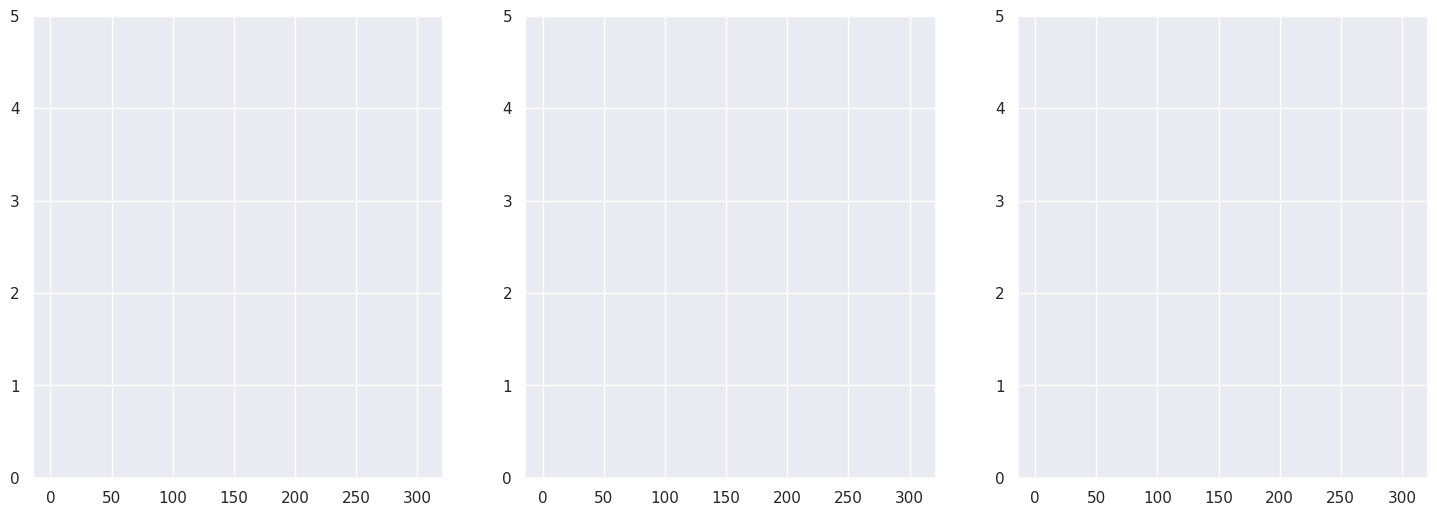

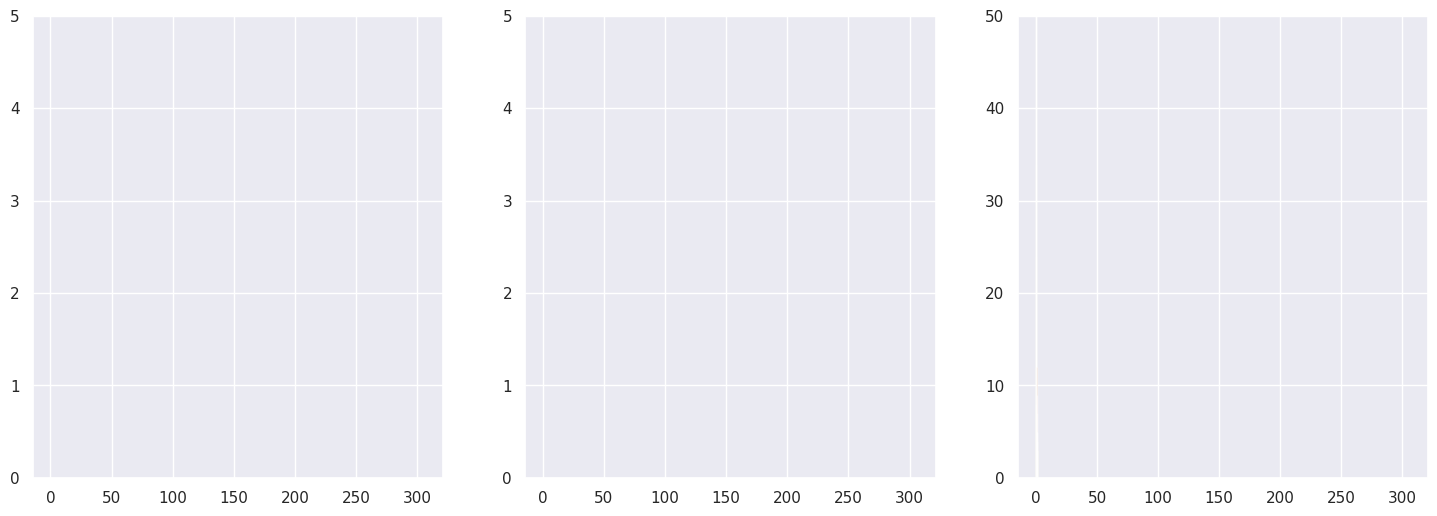

In [17]:
# show long insertions
df = df_chunks.query("dataset != 'jamendolyrics' and model == 'whisper'")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, dataset in enumerate(["jam-alt", "musdb", "dali_gt"]):
    df.query("algo == 'base' and target == 'original' and dataset == @dataset").query(
        "type == 'insert' & len > 5"
    )["len"].hist(
        bins=range(df_chunks["len"].min(), df_chunks["len"].max() + 2),
        alpha=0.5,
        label="base-original",
        ax=axes[idx],
    )
    axes[idx].set_ylim(0, 5)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, dataset in enumerate(["jam-alt", "musdb", "dali_gt"]):
    df.query("algo == 'rmsvad' and target == 'separated' and dataset == @dataset ").query(
        "type == 'insert' & len > 5"
    )["len"].hist(
        bins=range(df_chunks["len"].min(), df_chunks["len"].max() + 2),
        alpha=0.5,
        label="rmsvad-separated",
        ax=axes[idx],
    )
    axes[idx].set_ylim(0, 5)

display(
    df.query("algo == 'base' and target == 'original' and dataset == 'musdb'")
    .query("type == 'insert' & len >= 10")
    .sort_values("len", ascending=False)[["hyp", "len", "uid"]]
)
# display(df.query("algo == 'base' and target == 'original' and dataset == 'dali_gt'").query(
#         "type == 'insert' & len >= 0"
#     ).sort_values("len", ascending=False)["len"].sum())
display(
    df.query("algo == 'rmsvad' and target == 'separated' and dataset == 'musdb'")
    .query("type == 'insert' & len >=10")
    .sort_values("len", ascending=False)[["hyp", "len", "uid"]]
)
# display(df.query("algo == 'rmsvad' and target == 'separated' and dataset == 'dali_gt'").query(
#         "type == 'insert' & len >=0"
#     ).sort_values("len", ascending=False)["len"].sum())

# compute ins_len_ratio
df = df_songs.query("dataset != 'jamendolyrics'")
df["ins_len_ratio"] = df.apply(lambda row: row["ins"] / row["len"], axis=1)
df.sort_values(by="ins_len_ratio", ascending=False)

# plot
df.query("algo == 'base' and target == 'original'")["ins_len_ratio"].hist(
    bins=np.arange(0, 1, 0.05),
    alpha=0.5,
    label="base-original",  # type: ignore
)
df.query("algo == 'rmsvad' and target == 'separated'")["ins_len_ratio"].hist(
    bins=np.arange(0, 1, 0.05),
    alpha=0.5,
    label="rmsvad-separated",  # type: ignore
)
plt.ylim(0, 50)